In [1]:
!pip install yfinance pandas numpy matplotlib seaborn ta

In [2]:
!pip install matplotlib

In [16]:
!pip install seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
df=yf.download("RELIANCE.NS",start="2015-01-01",end="2025-01-01")
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2015-01-01,189.999771,190.877125,189.090320,189.657400,2963643
2015-01-02,189.496948,191.743828,189.229471,190.042616,7331366
2015-01-05,187.421265,190.641790,187.046782,189.379255,10103941
2015-01-06,178.915253,186.811408,178.037899,186.169449,18627980
2015-01-07,182.809845,183.772792,179.107860,179.129258,20720312


In [1]:
tickers = [
    "RELIANCE.NS",
    "TCS.NS",
    "INFY.NS",
    "HDFCBANK.NS",
    "ICICIBANK.NS"
]

start_date = "2015-01-01"
end_date = "2025-01-01"

Downloading: RELIANCE.NS


[*********************100%***********************]  1 of 1 completed


Downloading: TCS.NS


[*********************100%***********************]  1 of 1 completed


Downloading: INFY.NS


...

Downloading: HDFCBANK.NS


[*********************100%***********************]  1 of 1 completed


Downloading: ICICIBANK.NS


[*********************100%***********************]  1 of 1 completed



Dataset Shape: (12335, 7)

Columns: Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker'], dtype='object')
        Date       Close        High         Low        Open    Volume  \
0 2015-01-01  189.999817  190.877171  189.090366  189.657446   2963643   
1 2015-01-02  189.496948  191.743828  189.229471  190.042616   7331366   
2 2015-01-05  187.421249  190.641775  187.046767  189.379239  10103941   
3 2015-01-06  178.915237  186.811392  178.037884  186.169433  18627980   
4 2015-01-07  182.809814  183.772761  179.107830  179.129229  20720312   

        Ticker  
0  RELIANCE.NS  
1  RELIANCE.NS  
2  RELIANCE.NS  
3  RELIANCE.NS  
4  RELIANCE.NS  

Missing Values
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
Ticker    0
dtype: int64

Summary Statistics
                                Date         Close          High  \
count                          12335  12335.000000  12335.000000   
mean   2020-01-01 11:22:56.084312832    961.935179    971.65156

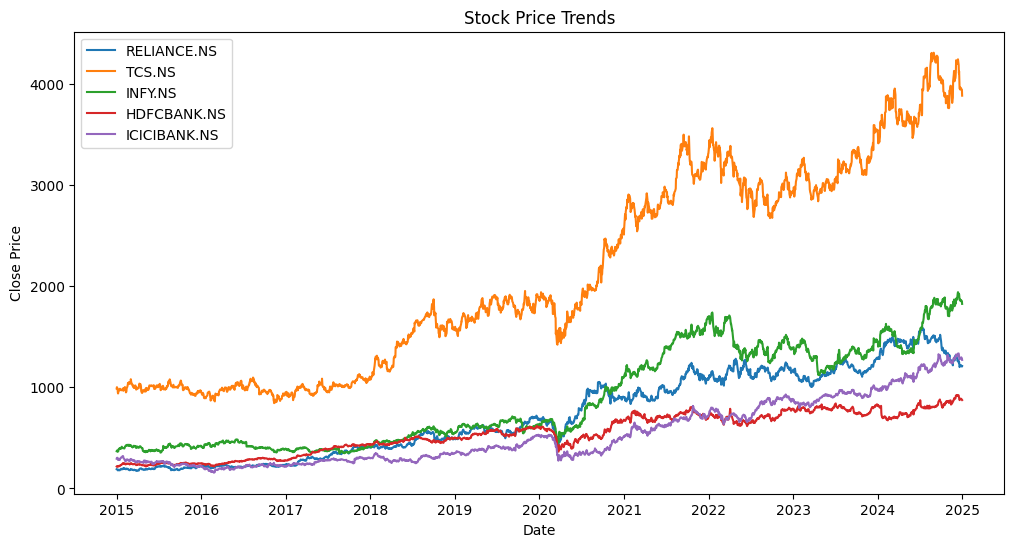


Basic Feature Engineering Completed

Adding Technical Indicators...

Technical Indicators Added

Target Variable Created


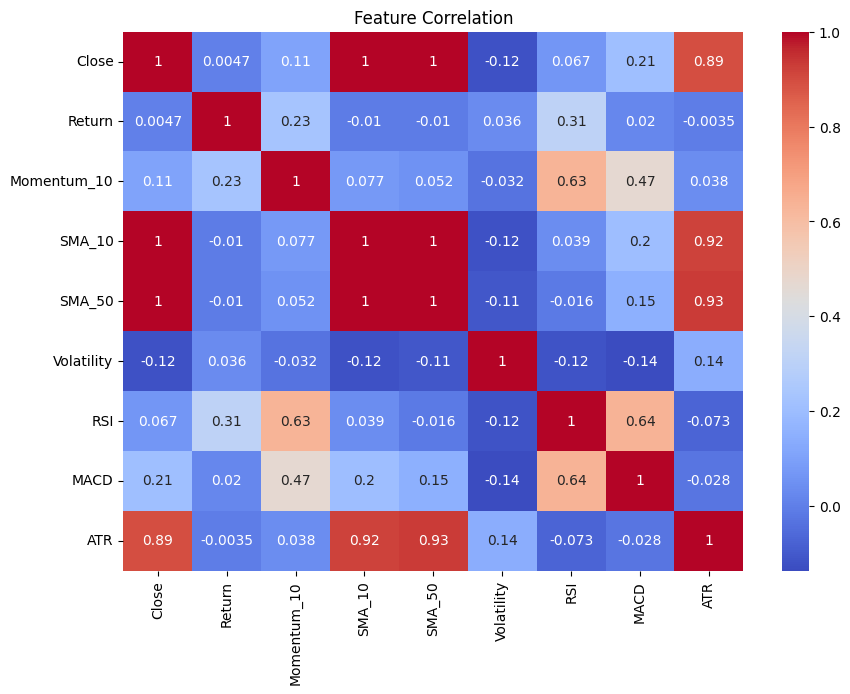


Final Dataset Shape: (12090, 20)

Dataset saved as stock_data.csv

Final Dataset Preview
           Date       Close        High         Low        Open   Volume  \
7450 2015-03-16  239.938889  241.387803  237.873881  238.444322  5348772   
7451 2015-03-17  241.422043  243.213222  237.953745  241.866976  5369304   
7452 2015-03-18  242.677032  244.582300  240.315384  241.901227  5148332   
7453 2015-03-19  240.087204  245.015837  239.288587  244.376932  5373572   
7454 2015-03-20  240.931473  241.752902  238.661101  239.813403  6483236   

           Ticker    Return  Momentum_10      SMA_10      SMA_50  Volatility  \
7450  HDFCBANK.NS  0.008536    -0.559052  242.622250  236.625779    0.015602   
7451  HDFCBANK.NS  0.006181    -5.590302  242.063220  237.109512    0.012678   
7452  HDFCBANK.NS  0.005198    -4.517914  241.611429  237.557879    0.012870   
7453  HDFCBANK.NS -0.010672    -2.989136  241.312515  237.991642    0.012223   
7454  HDFCBANK.NS  0.003517    -6.662704  240.646245 

In [ ]:
# ==========================================================
# Multi Stock EDA for ML Stock Prediction Project
# ==========================================================

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import ta

plt.rcParams["figure.figsize"] = (12,6)

# ==========================================================
# 1 Define Stocks
# ==========================================================

tickers = [
    "RELIANCE.NS",
    "TCS.NS",
    "INFY.NS",
    "HDFCBANK.NS",
    "ICICIBANK.NS"
]

start_date = "2015-01-01"
end_date = "2025-01-01"

# ==========================================================
# 2 Download Stock Data
# ==========================================================

def download_stock_data(tickers, start, end):

    all_data = []

    for ticker in tickers:

        print("Downloading:", ticker)

        temp = yf.download(ticker, start=start, end=end)

        temp = temp.reset_index()

        # Fix multi-index columns
        temp.columns = [col[0] if isinstance(col, tuple) else col for col in temp.columns]

        temp["Ticker"] = ticker

        all_data.append(temp)

    df = pd.concat(all_data, ignore_index=True)

    return df


df = download_stock_data(tickers, start_date, end_date)

print("\nDataset Shape:", df.shape)
print("\nColumns:", df.columns)
print(df.head())


# ==========================================================
# 3 Basic Dataset Info
# ==========================================================

print("\nMissing Values")
print(df.isnull().sum())

print("\nSummary Statistics")
print(df.describe())


# ==========================================================
# 4 Plot Stock Price Trends
# ==========================================================

for ticker in df["Ticker"].unique():

    stock = df[df["Ticker"] == ticker]

    plt.plot(stock["Date"], stock["Close"], label=ticker)

plt.title("Stock Price Trends")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()


# ==========================================================
# 5 Feature Engineering
# ==========================================================

df = df.sort_values(["Ticker","Date"])

# Daily Returns
df["Return"] = df.groupby("Ticker")["Close"].pct_change()

# Momentum
df["Momentum_10"] = df.groupby("Ticker")["Close"].diff(10)

# Moving Averages
df["SMA_10"] = df.groupby("Ticker")["Close"].rolling(10).mean().reset_index(level=0, drop=True)

df["SMA_50"] = df.groupby("Ticker")["Close"].rolling(50).mean().reset_index(level=0, drop=True)

# Volatility
df["Volatility"] = df.groupby("Ticker")["Return"].rolling(10).std().reset_index(level=0, drop=True)

print("\nBasic Feature Engineering Completed")


# ==========================================================
# 6 Add Technical Indicators
# ==========================================================

print("\nAdding Technical Indicators...")

# RSI
df["RSI"] = ta.momentum.RSIIndicator(df["Close"]).rsi()

# MACD
macd = ta.trend.MACD(df["Close"])
df["MACD"] = macd.macd()
df["MACD_signal"] = macd.macd_signal()

# Bollinger Bands
bb = ta.volatility.BollingerBands(df["Close"])
df["BB_high"] = bb.bollinger_hband()
df["BB_low"] = bb.bollinger_lband()

# ATR
atr = ta.volatility.AverageTrueRange(df["High"], df["Low"], df["Close"])
df["ATR"] = atr.average_true_range()

# VWAP
df["VWAP"] = (df["Close"] * df["Volume"]).cumsum() / df["Volume"].cumsum()

print("\nTechnical Indicators Added")


# ==========================================================
# 7 Create Target Variable
# ==========================================================

df["Target"] = df.groupby("Ticker")["Close"].shift(-1)

df["Target"] = (df["Target"] > df["Close"]).astype(int)

print("\nTarget Variable Created")


# ==========================================================
# 8 Correlation Analysis
# ==========================================================

features = [
    "Close","Return","Momentum_10","SMA_10","SMA_50",
    "Volatility","RSI","MACD","ATR"
]

corr = df[features].corr()

plt.figure(figsize=(10,7))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation")

plt.show()


# ==========================================================
# 9 Remove Missing Values
# ==========================================================

df = df.dropna()

print("\nFinal Dataset Shape:", df.shape)


# ==========================================================
# 10 Save Dataset
# ==========================================================

df.to_csv("stock_data.csv", index=False)

print("\nDataset saved as stock_data.csv")


# ==========================================================
# 11 Preview Final Dataset
# ==========================================================

print("\nFinal Dataset Preview")
print(df.head())